In [ ]:
!pip install torch torchvision scikit-learn matplotlib seaborn tqdm

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

import os

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
!unzip "/content/archive (3).zip" -d /content/dataset


Archive:  /content/archive (3).zip
replace /content/dataset/test/FAKE/0 (10).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/dataset/test/FAKE/0 (2).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/dataset/test/FAKE/0 (3).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
train_dir ="/content/dataset/train"
test_dir = "/content/dataset/test"

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)

print(train_dataset.classes)

['FAKE', 'REAL']


In [ ]:
from torch.utils.data import Subset
import numpy as np

# Get all labels
targets = np.array(train_dataset.targets)

# Get indices of each class
fake_indices = np.where(targets == 0)[0]   # FAKE
real_indices = np.where(targets == 1)[0]   # REAL

# Shuffle
np.random.shuffle(fake_indices)
np.random.shuffle(real_indices)

# Take 30k each
selected_fake = fake_indices[:30000]
selected_real = real_indices[:30000]

# Combine
selected_indices = np.concatenate([selected_fake, selected_real])

# Shuffle combined indices
np.random.shuffle(selected_indices)

train_subset = Subset(train_dataset, selected_indices)

In [ ]:
targets_test = np.array(test_dataset.targets)

fake_test = np.where(targets_test == 0)[0]
real_test = np.where(targets_test == 1)[0]

np.random.shuffle(fake_test)
np.random.shuffle(real_test)

selected_fake_test = fake_test[:3000]
selected_real_test = real_test[:3000]

selected_test_indices = np.concatenate([selected_fake_test, selected_real_test])

np.random.shuffle(selected_test_indices)

test_subset = Subset(test_dataset, selected_test_indices)

In [ ]:
from collections import Counter

labels = [train_dataset.targets[i] for i in selected_indices]
print(Counter(labels))

Counter({0: 30000, 1: 30000})


In [ ]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False, num_workers=2)

In [ ]:
from torchvision import models
import torch.nn as nn

model = models.resnet18(pretrained=True)

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

# Replace classifier
model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.fc.parameters(), lr=0.0001)

In [ ]:
def train_model(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader):

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total

    return running_loss/len(loader), accuracy

In [ ]:
def evaluate_model(model, loader):

    model.eval()

    correct = 0
    total = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():

        for images, labels in loader:

            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    accuracy = 100 * correct / total

    return accuracy, all_labels, all_preds

In [ ]:
epochs = 5

for epoch in range(epochs):

    loss, train_acc = train_model(model, train_loader)

    test_acc, _, _ = evaluate_model(model, test_loader)

    print(f"Epoch {epoch+1}")
    print(f"Loss: {loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2f}%")
    print(f"Test Accuracy: {test_acc:.2f}%")

100%|██████████| 1875/1875 [02:05<00:00, 14.95it/s]


Epoch 1
Loss: 0.4546
Train Accuracy: 79.29%
Test Accuracy: 84.82%


100%|██████████| 1875/1875 [02:01<00:00, 15.44it/s]


Epoch 2
Loss: 0.3515
Train Accuracy: 85.09%
Test Accuracy: 86.20%


100%|██████████| 1875/1875 [02:01<00:00, 15.42it/s]


Epoch 3
Loss: 0.3310
Train Accuracy: 85.90%
Test Accuracy: 86.68%


100%|██████████| 1875/1875 [02:00<00:00, 15.57it/s]


Epoch 4
Loss: 0.3239
Train Accuracy: 86.10%
Test Accuracy: 87.03%


100%|██████████| 1875/1875 [01:59<00:00, 15.65it/s]


Epoch 5
Loss: 0.3199
Train Accuracy: 86.33%
Test Accuracy: 87.38%


              precision    recall  f1-score   support

        Fake       0.87      0.89      0.88      3000
        Real       0.88      0.86      0.87      3000

    accuracy                           0.87      6000
   macro avg       0.87      0.87      0.87      6000
weighted avg       0.87      0.87      0.87      6000



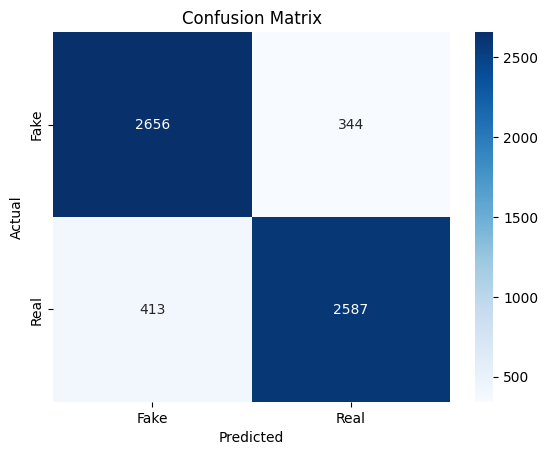

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

_, y_true, y_pred = evaluate_model(model, test_loader)

print(classification_report(
    y_true, y_pred,
    target_names=["Fake", "Real"]
))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake","Real"],
            yticklabels=["Fake","Real"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
